In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import os
import seaborn as sns
from utils.evaluation_utils import evaluation_metrics_helper

seed = 432
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Introduction
"insert intro about how anomaly detection is cool and data bla" <br>
Many deep learning models have shown good performance on forecasting, reconstruction **(insert papers)** <br>
and downstream tasks such as anomaly detection. While most papers focus on achieving SOTA results through clever improvements, <br>
this project aims at comparing how different architectural choices influence the types of anomalies detected. <br>
The dataset for this task was carefully chosen because it satisfied key constraints: <br>
- varied labeled anomaly types
- huge, multivariate dataset <br>
- distribution shifts, and non-obvious cross correlations across features. <br>

Four models/techniques are proposed for this task, each ordered in terms of increasing complexity: <br>
- pure lstm forecaster
- lstm autoencoder
- patchTST inspired transformer encoder

## Proposed Methodology and Experimental setup
### Training Setup

Training was performed using AdamW optimizers with learning rates  
ranging from 5e-4 to 1e-3. A warmup followed by cosine decay scheduler was  
used where the number of warmup steps depends on the dataset size. 

Early stopping was applied with variable patience and min_delta parameters.

All models were trained on GPU using Kaggle, Colab, or Modal environments.<br>
Models use batch_sizes ranging from 256 to 1024, depending on the <br>
GPU's used for a specific training session. <br>
Choice of GPU varied between:
- P100 (kaggle)
- A100 (colab)
- H100/H200 (modal/colab)
- B200 (modal)
<br><br>

<img src="images/image1.png" width="400"><br>
fig_1
<br> <br>

#### Residual calculation 
Once all the models trained, each model was used to compute <br>
anomaly scores from residual errors using a k-nearest neighbors <br>
approach in the residual space ```R_train```. <br><br>
The model first produces a prediction for each input window<br>
and the residual is obtained as the difference between <br>
the true and predicted values, flattened into a vector representation. <br>
These residuals are standardized using the mean and standard deviation <br>
computed over `R_train` 
<br><br>
<img src="images/image2.png" width="500"><br>
fig_2
<br> <br>
This gives an `anomaly_score` that represents "how anomalous" the current window is. <br>

#### Evaluation

Time points were labeled as anomalies if their `anomaly_scores` exceeded the threshold `t`. <br>
The threshold `t` was set to the `100% - 3.8%` percentile of `anomaly_scores` according to the <br>
known contamination rate in the dataset.<br>

A smoothing window was applied over the anomaly scores. <br>
The size of the smoothing window was determined over a grid search on the validation dataset.<br>
The metrics of comparison were F1/recall/precision.

### High level overview of each model
#### LSTM Forecaster

The pure lstm forecaster takes in an input window and passes it through <br> 
a Long Short-Term Memory (LSTM) neural network. Then uses a linear layer to project back into input space. <br><br>
<img src="images/lstm_f.png" width="600"><br>
fig.3 lstm forecaster diagram<br> <br>

#### LSTM Autoencoder

The lstm encoder-decoder takes in an input window passes it through an encoder similar to the previous model, <br>
but returns a tuple containing a tensor `out` representing the encoded input at each time step, <br>
the final hidden and final cell states `h0`, `c0`, and the input `x` itself used for teacher forcing during training. <br><br>
In order to vectorize the teacher forcing part, the `x` tensor is shifted to the right along the `L` dimension, <br>
and the first element along that dimension is replaced by 0 (or zero tensor if L > 1). <br>
The `out` and `x` tensors are then concatenated along the last dimension to give the lstm layer <br>
a combined representation of the previous true timestep + previous encoders output at that timestep.<br>
The combined representation and `(h0, c0)` are then fed into the decoder. <br><br>
<img src="images/lstm_ae_train.png" width="600"><br>
fig.4, lstm autoencoder diagram during training phase when teacher forcing is enabled <br>

At inference, and when shceduling sampling kicks in; instead of teacher forcing, <br>
the decoders output at each timestep is instead used as its next input rather than relying on the true window. <br>
So either scheduled sampling or autoregressive inference<br><br>

#### PatchTST Forecaster (Transformer Encoder)

bla bla bla blabla  blablablablablablablabla<br>
<img src="images/patch_tst.png" width="600"><br>
fig.5 [(Huo et al., 2025)](https://arxiv.org/html/2501.08620v1) Patch_TST diagram

### Preprocessing

All features are normalized using a RobustScaler fitted on the training data<br>
and applied consistently across validation and test splits.<br>

The time series is segmented using sliding windows, with a lookback window<br>
ranging from 100 to 256 depending on the model, and a forecast horizon of 4<br>
for forecasting-based approaches.<br>

Model errors are represented as residual vectors obtained by flattening the<br>
difference between predictions and targets.

Reversible Instance Normalization [(RevIN)](https://github.com/ts-kim/RevIN) is applied  
at the model input and output to mitigate distribution shifts.

## Results

### Final Model Parameters

| Model                  | Lookback | Horizon | Hidden / d_model | Layers / Blocks | Other Params                  | LR      | Batch | Epochs | best loss |
|----------------------|----------|---------|------------------|------------------|-------------------------------|---------|-------|--------|--------|
| LSTM Autoencoder     | 256      | –       | EDR = 3.0        | –                | Latent scaling via EDR        | 0.00225 | 512   | 30     |        |
| LSTM Forecaster      | 100      | 4       | 128              | 1 layer          | –                             | 0.001   | 128   | 50     | 0.0209 |
| PatchTST Forecaster  | 256      | 4       | 256              | 1 block          | 8 heads, dropout = 0.0        | 0.001   | 512   | 10     | 0.0200 |

These models weren't finetuned to the max because of computational constraints, and because <br>
models good forecasting/reconstruction losses don't always translate to good anomaly detectors. <br>

The objective was to train baseline models across different but comparable architectures. <br>
Therefore, some hyperparameters were selected using practical heuristics rather than <br>
exhaustive search. For example, the lookback window was chosen to be large enough to capture <br> 
temporal shifts in the data while remaining computationally tractable. Since anomalies in the <br>
CATS dataset are contiguous and span 500–1000 timesteps, the selected window sizes <br>
were chosen just sufficiently large while still being efficient to train with.<br>

In [196]:
root = "c:\\Architectural-Biases-in-Time-Series-Anomaly-Detection"
def create_dict(name):
    path = os.path.join(root, "saved_model_scores", name)
    with np.load(path) as data:
       results = {name: metric for name, metric in data.items()}
    return results

def load_scores(results):
    return (
        (results["v_scores"], 
        results["v_labels"], 
        results["v_categories"]),
        (results["t_scores"], 
        results["t_labels"], 
        results["t_categories"])
    )

In [194]:
lstm_f_results = create_dict("lstm_f_results.npz")
lstm_ae_results = create_dict("lstm_ae_results.npz")
transformer_f_results = create_dict("transformer_f_results.npz")

In [197]:
lstm_f_val_metrics, lstm_f_test_metrics = \
    load_scores(lstm_f_results)
transformer_val_metrics, transformer_test_metrics = \
    load_scores(transformer_f_results)
ae_val_metrics, ae_test_metrics = \
    load_scores(lstm_ae_results)

In [ ]:
def tune_smoothing_window(scores, labels, cats, name="None"):
    results = []

    for window in window_grid:
        F1, precision, _ = evaluation_metrics_helper(scores, labels, cats, window)
        results.append({
            "model_name": name,
            "F1": round(F1.item(), 2),
            "smoothing_window": window
        })

    results.sort(key=lambda x: x['F1'], reverse=True)
    return pd.Series(results[0])

#### Tuning Smoothing window over validation dataset

In [ ]:
window_grid = np.linspace(1, 1000, 20).astype(int)

pd.DataFrame(
    [tune_smoothing_window(*lstm_f_val_metrics, "lstm"),
    tune_smoothing_window(*transformer_val_metrics, "transformer"),
    tune_smoothing_window(*ae_val_metrics, "LSTM AutoEncoder")]
)

#### Test Results

In [ ]:
def category_summary(scores, labels, cats, window, name):
    series = []
    F1, precision, cat_dict = evaluation_metrics_helper(scores, labels, cats, window)
    cat_dict["Precision"] = np.round(precision, 3)
    cat_dict["F1"] = np.round(F1, 3)

    series.append(pd.Series(cat_dict, name = name))
    return pd.concat(series, axis=1).T

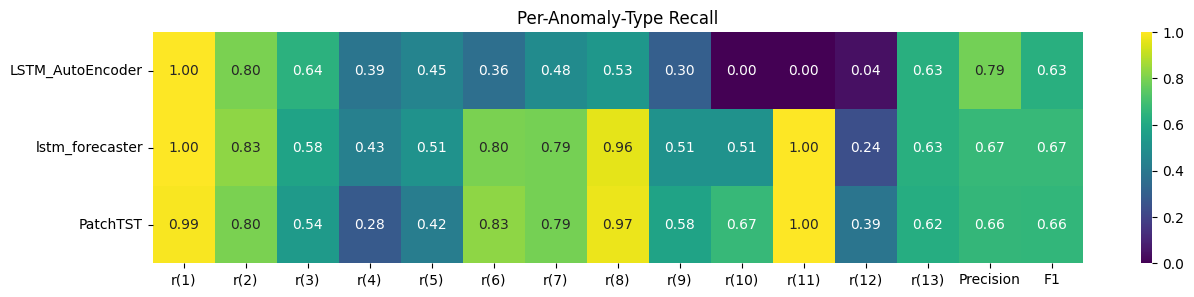

In [201]:
lstm_autoencoder_series = category_summary(*ae_test_metrics, 526, "LSTM_AutoEncoder")
lstm_forecaster_series = category_summary(*lstm_f_test_metrics, 476, "lstm_forecaster")
patchTST_series = category_summary(*transformer_test_metrics, 316, "PatchTST")
category_df = pd.concat([lstm_autoencoder_series, lstm_forecaster_series, patchTST_series])

cols = [c for c in category_df.columns if ("r" in c or "F1" in c)]
plt.figure(figsize=(15, 3))
sns.heatmap(category_df[cols], annot=True, fmt=".2f", cmap="viridis")
plt.title("Per-Anomaly-Type Recall")
plt.show()